In [44]:
import os
import random
from pathlib import Path
from datasets import load_dataset
import sentencepiece as spm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from tqdm.auto import tqdm

import sacrebleu

In [2]:
ds = load_dataset("Helsinki-NLP/opus-100", "en-pl")

# Create tokens

In [3]:
def extract_texts(dataset, split, n_samples=None):
    src = []
    tgt = []
    it = dataset[split]
    if n_samples:
        it = it.select(range(min(n_samples, len(it))))
    for ex in it:
        tr = ex["translation"]
        pl = tr.get("pl")
        en = tr.get("en")
        if pl and en:
            src.append(pl.strip())
            tgt.append(en.strip())
    return src, tgt


n_samples=50000 # for quick dev, for full training use None
train_src, train_tgt = extract_texts(ds, "train", n_samples=n_samples)
val_src, val_tgt = extract_texts(ds, "validation")
test_src, test_tgt = extract_texts(ds, "test")

print("Train pairs:", len(train_src))
print("Validation pairs:", len(val_src))
print("Test pairs:", len(test_src))

Train pairs: 50000
Validation pairs: 2000
Test pairs: 2000


In [45]:
data_dir = Path("./opus_data")
spm_model_prefix = data_dir / "spm"
vocab_size = 8000
max_src_len = 128
max_tgt_len = 128
batch_size = 64
seed = 42

os.makedirs(data_dir, exist_ok=True)
random.seed(seed)

In [5]:
# Write combined training corpus file for SentencePiece
train_txt = data_dir / "spm_train.txt"
with open(train_txt, "w", encoding="utf-8") as fout:
    # Write Polish and English lines interleaved (or sequentially)
    for s in train_src:
        fout.write(s.replace("\n", " ") + "\n")
    for t in train_tgt:
        fout.write(t.replace("\n", " ") + "\n")

In [8]:
spm_args = (
    f"--input={str(train_txt)} "
    f"--model_prefix={str(spm_model_prefix)} "
    f"--vocab_size={vocab_size} "
    f"--model_type=bpe "
    f"--character_coverage=1.0 "
    f"--pad_id=0 --unk_id=1 --bos_id=2 --eos_id=3 "
    f"--pad_piece=<pad> --unk_piece=<unk> --bos_piece=<s> --eos_piece=</s>"
)
spm.SentencePieceTrainer.Train(spm_args)

In [15]:
sp = spm.SentencePieceProcessor()
sp.Load(str(spm_model_prefix) + ".model")

print("Vocab size:", sp.GetPieceSize())
print("Sample encoding:", sp.EncodeAsIds("To jest mój dom."))
# IDs for special tokens:
pad_id = sp.PieceToId("<pad>")
unk_id = sp.PieceToId("<unk>")
sos_id = sp.PieceToId("<s>")
eos_id = sp.PieceToId("</s>")
print("pad,unk,sos,eos ids:", pad_id, unk_id, sos_id, eos_id)

Vocab size: 8000
Sample encoding: [224, 138, 1460, 866, 7673]
pad,unk,sos,eos ids: 0 1 2 3


In [17]:
def encode_sentence(s: str, max_len: int):
    ids = sp.EncodeAsIds(s)
    # truncate (reserve space for <s> and </s> in decoder side where needed)
    if len(ids) > max_len:
        ids = ids[:max_len]
    return ids

class PlEnOpusDataset(Dataset):
    def __init__(self, src_texts, tgt_texts, max_src_len=128, max_tgt_len=128):
        assert len(src_texts) == len(tgt_texts)
        self.src_texts = src_texts
        self.tgt_texts = tgt_texts
        self.max_src_len = max_src_len
        self.max_tgt_len = max_tgt_len

    def __len__(self):
        return len(self.src_texts)

    def __getitem__(self, idx):
        src = self.src_texts[idx]
        tgt = self.tgt_texts[idx]
        src_ids = encode_sentence(src, self.max_src_len)
        tgt_ids = encode_sentence(tgt, self.max_tgt_len - 1)  # leave room for eos if needed
        decoder_input = [sos_id] + tgt_ids
        decoder_target = tgt_ids + [eos_id]
        return torch.tensor(src_ids, dtype=torch.long), torch.tensor(decoder_input, dtype=torch.long), torch.tensor(decoder_target, dtype=torch.long)

In [18]:
def collate_fn(batch):
    # batch: list of tuples (src_ids, decoder_input_ids, decoder_target_ids)
    src_list, dec_in_list, dec_tgt_list = zip(*batch)
    # pad with pad_id
    src_padded = pad_sequence(src_list, batch_first=True, padding_value=pad_id)
    dec_in_padded = pad_sequence(dec_in_list, batch_first=True, padding_value=pad_id)
    dec_tgt_padded = pad_sequence(dec_tgt_list, batch_first=True, padding_value=pad_id)

    # lengths (useful if you want to pack_padded_sequence)
    src_lens = torch.tensor([len(x) for x in src_list], dtype=torch.long)
    dec_lens = torch.tensor([len(x) for x in dec_in_list], dtype=torch.long)

    return {
        "src_ids": src_padded,
        "src_lens": src_lens,
        "dec_input_ids": dec_in_padded,
        "dec_target_ids": dec_tgt_padded,
        "dec_lens": dec_lens
    }

# Create datasets and dataloaders (for dev you may want subset)
train_dataset = PlEnOpusDataset(train_src, train_tgt, max_src_len=max_src_len, max_tgt_len=max_tgt_len)
val_dataset = PlEnOpusDataset(val_src, val_tgt, max_src_len=max_src_len, max_tgt_len=max_tgt_len)
test_dataset = PlEnOpusDataset(test_src, test_tgt, max_src_len=max_src_len, max_tgt_len=max_tgt_len)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

In [19]:
batch = next(iter(train_loader))
print("src_ids shape:", batch["src_ids"].shape)
print("dec_input_ids shape:", batch["dec_input_ids"].shape)
print("dec_target_ids shape:", batch["dec_target_ids"].shape)
print("src_lens:", batch["src_lens"][:8])
print("dec_lens:", batch["dec_lens"][:8])

def decode_ids(ids):
    return sp.DecodeIds(ids.tolist())

print("Example src text (reconstructed):", decode_ids(batch["src_ids"][0][batch["src_ids"][0] != pad_id]))
print("Example decoder input (reconstructed):", decode_ids(batch["dec_input_ids"][0][batch["dec_input_ids"][0] != pad_id]))
print("Example decoder target (reconstructed):", decode_ids(batch["dec_target_ids"][0][batch["dec_target_ids"][0] != pad_id]))

src_ids shape: torch.Size([32, 105])
dec_input_ids shape: torch.Size([32, 80])
dec_target_ids shape: torch.Size([32, 80])
src_lens: tensor([ 8, 11,  9,  9,  3, 24,  7, 11])
dec_lens: tensor([ 8, 14, 13, 11,  3, 19, 13, 13])
Example src text (reconstructed): Umarł w moich ramionach.
Example decoder input (reconstructed): He died in my arms.
Example decoder target (reconstructed): He died in my arms.


# Train utils

In [46]:
def compute_bleu(references, hypotheses):
    bleu = sacrebleu.corpus_bleu(hypotheses, [references])
    return bleu.score

In [47]:
def train_epoch(model, dataloader, optimizer, device, clip=2.0):
    model.train()
    total_loss = 0.0
    total_tokens = 0
    for batch in tqdm(dataloader, desc="train"):
        src = batch["src_ids"].to(device)
        dec_in = batch["dec_input_ids"].to(device)
        dec_tgt = batch["dec_target_ids"].to(device)
        optimizer.zero_grad()
        logits = model(src, dec_in)
        B, T, V = logits.size()
        logits_flat = logits.view(B * T, V)
        targets_flat = dec_tgt.view(B * T)
        loss = criterion(logits_flat, targets_flat)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip)
        optimizer.step()

        non_pad = (targets_flat != pad_id).sum().item()
        total_loss += loss.item() * non_pad
        total_tokens += non_pad

    avg_loss = total_loss / total_tokens if total_tokens > 0 else 0.0
    return avg_loss

In [48]:
def evaluate(model, dataloader, device, max_decode_len=80):
    model.eval()
    total_loss = 0.0
    total_tokens = 0
    preds = []
    refs = []
    with torch.no_grad():
        for i, batch in enumerate(tqdm(dataloader, desc="eval")):
            src = batch["src_ids"].to(device)
            dec_in = batch["dec_input_ids"].to(device)
            dec_tgt = batch["dec_target_ids"].to(device)
            logits = model(src, dec_in)
            B, T, V = logits.size()
            logits_flat = logits.view(B*T, V)
            targets_flat = dec_tgt.view(B*T)
            loss = criterion(logits_flat, targets_flat)

            non_pad = (targets_flat != pad_id).sum().item()
            total_loss += loss.item() * non_pad
            total_tokens += non_pad

            preds_ids = model.greedy_decode(src, max_len=max_decode_len, device=device)
            for b in range(preds_ids.size(0)):
                pred_seq = preds_ids[b]
                # cut at end-of-seq token
                pred_list = pred_seq.cpu().tolist()
                if eos_id in pred_list:
                    idx = pred_list.index(eos_id)
                    pred_list = pred_list[:idx]
                hyp = sp.DecodeIds([int(x) for x in pred_list])
                preds.append(hyp)

            for b in range(dec_tgt.size(0)):
                ref_seq = dec_tgt[b].cpu().tolist()
                if eos_id in ref_seq:
                    idx = ref_seq.index(eos_id)
                    ref_seq = ref_seq[:idx]
                ref_text = sp.DecodeIds([int(x) for x in ref_seq if x != pad_id])
                refs.append(ref_text)

    avg_loss = total_loss / total_tokens if total_tokens > 0 else 0.0
    n = min(len(refs), len(preds))
    if n == 0:
        bleu = 0.0
    else:
        bleu = compute_bleu(refs[:n], preds[:n])
    return avg_loss, bleu

In [49]:
def select_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    elif torch.cuda.is_available():
        return torch.device("cuda")
    else:
        return torch.device("cpu")


device = select_device()

# No Attention Encoder-Decoder

In [50]:
class EncoderGRU(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, n_layers=1, dropout=0.1, pad_id=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.gru = nn.GRU(embed_dim, hidden_size, num_layers=n_layers, batch_first=True, dropout=dropout if n_layers>1 else 0.0)
        self.hidden_size = hidden_size
        self.n_layers = n_layers

    def forward(self, src_ids, src_lens=None):
        # src_ids: (B, src_len)
        emb = self.embedding(src_ids)               # (B, src_len, embed_dim)
        # Not using pack_padded here for simplicity (ok for moderate dataset); can add later.
        outputs, hidden = self.gru(emb)             # outputs: (B, src_len, hidden), hidden: (n_layers, B, hidden)
        return outputs, hidden

class DecoderGRU(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, n_layers=1, dropout=0.1, pad_id=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.gru = nn.GRU(embed_dim, hidden_size, num_layers=n_layers, batch_first=True, dropout=dropout if n_layers>1 else 0.0)
        self.output_proj = nn.Linear(hidden_size, vocab_size)

    def forward(self, dec_input_ids, hidden):
        # dec_input_ids: (B, tgt_len)  -- already includes <s> at start for training
        # hidden: (n_layers, B, hidden)  -- initial hidden from encoder
        emb = self.embedding(dec_input_ids)        # (B, tgt_len, embed_dim)
        outputs, hidden = self.gru(emb, hidden)    # outputs: (B, tgt_len, hidden)
        logits = self.output_proj(outputs)         # (B, tgt_len, vocab_size)
        return logits, hidden

class Seq2SeqGRU(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, encoder_layers=1, decoder_layers=1, dropout=0.1, pad_id=0):
        super().__init__()
        self.encoder = EncoderGRU(vocab_size, embed_dim, hidden_size, n_layers=encoder_layers, dropout=dropout, pad_id=pad_id)
        self.decoder = DecoderGRU(vocab_size, embed_dim, hidden_size, n_layers=decoder_layers, dropout=dropout, pad_id=pad_id)
        self.pad_id = pad_id
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size

        # Optionally tie embeddings between encoder and decoder to reduce params:
        # self.decoder.embedding.weight = self.encoder.embedding.weight

    def forward(self, src_ids, dec_input_ids):
        """
        Forward pass for training (teacher forcing): returns logits for each decoder timestep.
        src_ids: (B, src_len)
        dec_input_ids: (B, tgt_len)  # includes <s> at start
        returns: logits (B, tgt_len, vocab_size)
        """
        _, enc_hidden = self.encoder(src_ids)
        # If encoder is multi-layer and decoder different, adapt hidden appropriately.
        logits, _ = self.decoder(dec_input_ids, enc_hidden)
        return logits

    def greedy_decode(self, src_ids, max_len=100, device=None):
        """
        Greedy decode for a batch.
        src_ids: (B, src_len)
        returns: Tensor (B, max_len) with predicted ids (including eos if generated)
        """
        device = device or next(self.parameters()).device
        batch_size = src_ids.size(0)
        _, enc_hidden = self.encoder(src_ids.to(device))   # encoder on device
        # Start tokens
        ys = torch.full((batch_size, 1), sos_id, dtype=torch.long, device=device)  # (B,1)
        hidden = enc_hidden
        outputs = []
        for t in range(max_len):
            logits, hidden = self.decoder(ys[:, -1:].to(device), hidden)  # pass last token only (B,1)
            # logits: (B, 1, vocab)
            token_logits = logits[:, -1, :]                           # (B, vocab)
            next_tokens = token_logits.argmax(dim=-1, keepdim=True)   # (B,1)
            outputs.append(next_tokens)
            ys = torch.cat([ys, next_tokens], dim=1)                  # accumulate to feed maybe required by decoder (not strictly for single-step GRU)
            # optional early stop check: break if all predicted eos
            if (next_tokens == eos_id).all():
                break
        # Concatenate outputs: list of (B,1) -> (B, out_len)
        out = torch.cat(outputs, dim=1)
        return out


In [31]:
vocab_size = sp.GetPieceSize()
embed_dim = 256
hidden_size = 512

model = Seq2SeqGRU(vocab_size=vocab_size, embed_dim=embed_dim, hidden_size=hidden_size,
                   encoder_layers=1, decoder_layers=1, dropout=0.3, pad_id=pad_id).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=pad_id)
optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

In [35]:
ckpt_dir = Path("seq2seq_checkpoints")
ckpt_dir.mkdir(parents=True, exist_ok=True)

n_epochs = 10
best_val_bleu = -1.0
history = {"train_loss": [], "val_loss": [], "val_bleu": []}

patience = 3
no_improve = 0

for epoch in range(1, n_epochs+1):
    print(f"\n=== Epoch {epoch}/{n_epochs} ===")
    train_loss = train_epoch(model, train_loader, optimizer, device, clip=2.0)
    val_loss, val_bleu = evaluate(model, val_loader, device, max_decode_len=80)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_bleu"].append(val_bleu)

    print(f"Epoch {epoch} Train loss={train_loss:.4f}  Val loss={val_loss:.4f}  Val BLEU={val_bleu:.3f}")

    if val_bleu > best_val_bleu:
        best_val_bleu = val_bleu
        no_improve = 0
        ckpt_path = ckpt_dir / f"best_seq2seq_epoch{epoch}_bleu{val_bleu:.2f}.pt"
        torch.save({
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "epoch": epoch,
            "val_bleu": val_bleu,
            "vocab_size": vocab_size,
        }, ckpt_path)
        print("Saved best checkpoint:", ckpt_path)
    else:
        no_improve += 1
        if no_improve >= patience:
            print("No improvement for", patience, "epochs. Early stopping.")
            break



=== Epoch 1/10 ===


eval:  49%|████▉     | 31/63 [00:05<00:06,  5.24it/s]


Epoch 1 Train loss=4.7855  Val loss=4.2792  Val BLEU=1.056
Saved best checkpoint: seq2seq_checkpoints/best_seq2seq_epoch1_bleu1.06.pt

=== Epoch 2/10 ===


eval:  49%|████▉     | 31/63 [00:04<00:05,  6.25it/s]


Epoch 2 Train loss=3.8477  Val loss=4.0028  Val BLEU=1.941
Saved best checkpoint: seq2seq_checkpoints/best_seq2seq_epoch2_bleu1.94.pt

=== Epoch 3/10 ===


...

Epoch 8 Train loss=2.1697  Val loss=4.1543  Val BLEU=3.541
Saved best checkpoint: seq2seq_checkpoints/best_seq2seq_epoch8_bleu3.54.pt

=== Epoch 9/10 ===


eval:  49%|████▉     | 31/63 [00:05<00:05,  5.72it/s]


Epoch 9 Train loss=1.9808  Val loss=4.2833  Val BLEU=3.537

=== Epoch 10/10 ===


eval:  49%|████▉     | 31/63 [00:05<00:05,  5.83it/s]

Epoch 10 Train loss=1.8112  Val loss=4.3807  Val BLEU=3.436


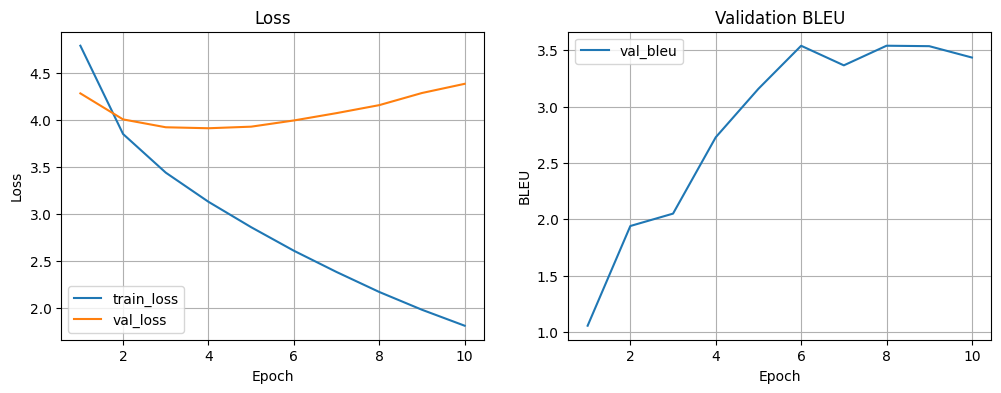

In [36]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epochs, history["train_loss"], label="train_loss")
plt.plot(epochs, history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(epochs, history["val_bleu"], label="val_bleu")
plt.xlabel("Epoch")
plt.ylabel("BLEU")
plt.legend()
plt.grid(True)
plt.show()

In [37]:
# find best checkpoint
ckpt_files = sorted(list(ckpt_dir.glob("best_seq2seq_*.pt")))
if len(ckpt_files)==0:
    print("No checkpoints saved.")
else:
    best_ckpt = ckpt_files[-1]   # sorted by name includes BLEU in name; adjust if needed
    print("Loading", best_ckpt)
    ckpt = torch.load(best_ckpt, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    model.to(device)
    model.eval()
    test_loss, test_bleu = evaluate(model, test_loader, device, max_decode_len=80)
    print(f"Test loss: {test_loss:.4f}, Test BLEU: {test_bleu:.3f}")


Loading seq2seq_checkpoints/best_seq2seq_epoch8_bleu3.54.pt


eval:  98%|█████████▊| 62/63 [00:10<00:00,  6.07it/s]

Test loss: 4.2356, Test BLEU: 2.754


# Add Attention

In [52]:
class LuongAttention(nn.Module):
    """Luong 'general' attention."""
    def __init__(self, hidden_size):
        super().__init__()
        self.Wa = nn.Linear(hidden_size, hidden_size, bias=False)

    def forward(self, decoder_hidden, encoder_outputs, mask=None):
        """
        decoder_hidden: (B, hidden) — current decoder hidden state
        encoder_outputs: (B, src_len, hidden)
        mask: (B, src_len) with 0 for PAD, 1 for real tokens
        Returns:
            context: (B, hidden)
            attn_weights: (B, src_len)
        """
        # (B, hidden) -> (B, 1, hidden)
        dec_hidden = self.Wa(decoder_hidden).unsqueeze(1)
        # Compute alignment scores: (B, 1, hidden) * (B, src_len, hidden)^T -> (B, src_len)
        scores = torch.bmm(dec_hidden, encoder_outputs.transpose(1, 2)).squeeze(1)  # (B, src_len)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attn_weights = F.softmax(scores, dim=-1)  # (B, src_len)
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs)  # (B, 1, hidden)
        context = context.squeeze(1)
        return context, attn_weights

In [53]:
class DecoderGRUWithAttention(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, n_layers=1, dropout=0.1, pad_id=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.gru = nn.GRU(embed_dim, hidden_size, num_layers=n_layers, batch_first=True, dropout=dropout if n_layers > 1 else 0.0)
        self.attn = LuongAttention(hidden_size)
        self.concat = nn.Linear(hidden_size * 2, hidden_size)
        self.output_proj = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, dec_input_ids, hidden, encoder_outputs, mask=None):
        """
        dec_input_ids: (B, tgt_len)
        hidden: (n_layers, B, hidden)
        encoder_outputs: (B, src_len, hidden)
        """
        emb = self.dropout(self.embedding(dec_input_ids))  # (B, tgt_len, embed_dim)
        outputs = []
        h = hidden
        for t in range(dec_input_ids.size(1)):
            inp = emb[:, t:t+1, :]  # (B,1,embed)
            out, h = self.gru(inp, h)  # out: (B,1,hidden)
            out = out.squeeze(1)
            context, attn_weights = self.attn(out, encoder_outputs, mask)
            concat_input = torch.cat([out, context], dim=-1)
            out_combined = torch.tanh(self.concat(concat_input))
            logits = self.output_proj(out_combined)
            outputs.append(logits.unsqueeze(1))
        outputs = torch.cat(outputs, dim=1)  # (B, tgt_len, vocab)
        return outputs, h


In [54]:
class Seq2SeqGRU_Attn(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, encoder_layers=1, decoder_layers=1, dropout=0.1, pad_id=0):
        super().__init__()
        self.encoder = EncoderGRU(vocab_size, embed_dim, hidden_size, n_layers=encoder_layers, dropout=dropout, pad_id=pad_id)
        self.decoder = DecoderGRUWithAttention(vocab_size, embed_dim, hidden_size, n_layers=decoder_layers, dropout=dropout, pad_id=pad_id)
        self.pad_id = pad_id

    def forward(self, src_ids, dec_input_ids, src_mask=None):
        encoder_outputs, enc_hidden = self.encoder(src_ids)
        logits, _ = self.decoder(dec_input_ids, enc_hidden, encoder_outputs, mask=src_mask)
        return logits

    def greedy_decode(self, src_ids, max_len=100, device=None):
        device = device or next(self.parameters()).device
        self.eval()
        with torch.no_grad():
            encoder_outputs, hidden = self.encoder(src_ids.to(device))
            mask = (src_ids != self.pad_id).to(device)
            batch_size = src_ids.size(0)
            ys = torch.full((batch_size, 1), sos_id, dtype=torch.long, device=device)
            outputs = []
            for _ in range(max_len):
                logits, hidden = self.decoder(ys[:, -1:], hidden, encoder_outputs, mask)
                next_token = logits[:, -1, :].argmax(dim=-1, keepdim=True)
                outputs.append(next_token)
                ys = torch.cat([ys, next_token], dim=1)
                if (next_token == eos_id).all():
                    break
            return torch.cat(outputs, dim=1)


In [55]:
attn_model = Seq2SeqGRU_Attn(
    vocab_size=vocab_size,
    embed_dim=256,
    hidden_size=512,
    dropout=0.3,
    pad_id=pad_id
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=pad_id)
optimizer = Adam(attn_model.parameters(), lr=1e-3, weight_decay=1e-5)

In [ ]:
ckpt_dir = Path("seq2seq_attn_checkpoints")
ckpt_dir.mkdir(parents=True, exist_ok=True)

n_epochs = 10
best_val_bleu = -1.0
history = {"train_loss": [], "val_loss": [], "val_bleu": []}

patience = 3
no_improve = 0

for epoch in range(1, n_epochs+1):
    print(f"\n=== Epoch {epoch}/{n_epochs} ===")
    train_loss = train_epoch(attn_model, train_loader, optimizer, device, clip=2.0)
    val_loss, val_bleu = evaluate(attn_model, val_loader, device, max_decode_len=80)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_bleu"].append(val_bleu)

    print(f"Epoch {epoch} Train loss={train_loss:.4f}  Val loss={val_loss:.4f}  Val BLEU={val_bleu:.3f}")

    if val_bleu > best_val_bleu:
        best_val_bleu = val_bleu
        no_improve = 0
        ckpt_path = ckpt_dir / f"best_seq2seq_epoch{epoch}_bleu{val_bleu:.2f}.pt"
        torch.save({
            "model_state": attn_model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "epoch": epoch,
            "val_bleu": val_bleu,
            "vocab_size": vocab_size,
        }, ckpt_path)
        print("Saved best checkpoint:", ckpt_path)
    else:
        no_improve += 1
        if no_improve >= patience:
            print("No improvement for", patience, "epochs. Early stopping.")
            break



=== Epoch 1/10 ===


train:  22%|██▏       | 343/1563 [01:21<03:20,  6.09it/s]